# EDA и бинарная классификация на датасете «Spaceship Titanic»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Spaceship Titanic  

**Выполнил:** Бреславская Ирина  
**Группа:** ПКТб-23-1  
**Преподаватель:** Спирин Игорь Сергеевич 

**Ссылка на репозиторий:** https://github.com/breslavskayaira/ml-course-breslavskaya
**Путь к модулю:** module-1-spaceship-titanic/notebook.ipynb  
**Дата сдачи:** 2026-09-29

## Введение

**Задача:** бинарная классификация — предсказать, был ли пассажир транспортирован в другое измерение (`Transported = True`) или нет (`False`).

**ML-проект** — это создание модели, которая учится на данных и решает задачу. Цикл: сбор данных → обучение → внедрение → мониторинг → переобучение (и так по кругу).

**Почему выбран Spaceship Titanic, а не базовый Titanic:**
Выбран Spaceship Titanic как более сложный датасет. По сравнению с базовым «Титаником» он содержит:
- больше данных (8693 строки против 891);
- пропуски почти во всех столбцах (~2% каждый);
- смешанные типы признаков (числовые, категориальные, булевы);
- скрытые закономерности в `PassengerId` (группы) и `Cabin` (палуба, сторона);

**Почему классификация, а не регрессия:** целевая переменная бинарная (True/False), а не непрерывная.

**Метрика:** основная — ROC-AUC, так как классы почти сбалансированы (50.36% / 49.64%), и ROC-AUC не зависит от порога. Accuracy может вводить в заблуждение при выборе порога. Ошибка «не транспортирован, а на самом деле транспортирован» (FN) и обратная (FP) примерно равнозначны, но ROC-AUC даёт общую оценку ранжирования. В этой задаче важно не ошибиться в предсказании «транспортирован» (ложноположительные и ложноотрицательные ошибки). Будем смотреть на **F1** и **ROC-AUC**, Accuracy — как дополнительную.

**Цель работы:**
1. Провести полный EDA датасета Spaceship Titanic.
2. Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
3. Реализовать функцию предсказания для нового пассажира.

## Теоретическая часть

**EDA (Exploratory Data Analysis)** — разведочный анализ данных. Помогает понять структуру, выявить пропуски, выбросы, связи между признаками. 
Шаги:
1. Загрузка и первичный осмотр: .shape, .info(), .head(), проверка типов данных.
2. Описательная статистика: .describe() (среднее, медиана, квартили, std), проверка распределений.
3. Визуализация: гистограммы, boxplot (для выбросов), heatmap (корреляции), scatter plot (связи).
4. Выводы: какие признаки требуют чистки, какие — преобразования, есть ли дисбаланс классов.

**Пропуски (NaN)** — отсутствующие значения. Возникают из-за ошибок сбора, потери данных. 
Стратегии: 
1. Удаление: если пропусков < 5% или если признак неинформативен.
2. Заполнение: средним (если распределение нормальное), медианой (если есть выбросы), модой (для категорий).
3. Предсказание: обучение модели (KNN, Iterative Imputer) для восстановления пропусков.
4. Оставление как отдельная категория: иногда сам факт пропуска несет информацию (например, «не указан доход»).

**Кодирование категорий:**  
- Label Encoding — присваивает каждой категории число (порядок).  
- One-Hot Encoding — создаёт бинарные столбцы для каждой категории.  
Для номинальных признаков лучше One-Hot, для порядковых — Label.

**Масштабирование:**  
- StandardScaler — приводит к среднему 0 и std 1. Хорошо работает, если данные близки к нормальному распределению.
- MinMaxScaler — сжимает в диапазон [0, 1]. Полезно, когда важны границы (например, для нейросетей).
- RobustScaler — использует медиану и межквартильный размах, устойчив к выбросам. Когда нужно: для моделей, чувствительных к масштабу (Logistic Regression, SVM, KNN, нейросети).

**Feature Engineering** — создание новых признаков из существующих для улучшения качества модели (например, Family_Size, Is_Alone, Age_Group). Хороший Feature Engineering часто дает больший прирост, чем смена модели.

**Метрики классификации:**
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
$$Precision = \frac{TP}{TP + FP}, \quad Recall = \frac{TP}{TP + FN}$$
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$
$ROC-AUC$ — площадь под ROC-кривой, показывает способность модели разделять классы.

| Метрика | Что показывает |
|---------|----------------|
| Accuracy | Доля правильных ответов |
| Precision | Точность предсказания «1» |
| Recall | Полнота обнаружения «1» |
| F1 | Баланс Precision и Recall |
| ROC-AUC | Качество ранжирования |

**Особенность Spaceship Titanic:**
Большинство пропусков можно заполнить не статистикой, а логическими правилами, найденными через EDA. Например:
- Пассажиры в CryoSleep не тратят деньги → все траты = 0.
- Дети (Age ≤ 12) не тратят деньги → все траты = 0.
- Пассажиры из одной группы (по PassengerId) часто имеют общий HomePlanet и Destination.

## Описание данных

**Источник:** Kaggle — [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)

Spaceship Titanic — это межзвёздный пассажирский корабль, который во время полёта столкнулся с пространственно-временной аномалией. Почти половина пассажиров была перемещена в другое измерение. Задача — предсказать, какие именно пассажиры были перемещены (Transported = True).

**Структура:**

Объём данных:
Обучающая выборка (train.csv): 8693 записи

Тестовая выборка (test.csv): 4277 записей

Количество признаков: 13 (без учёта целевой переменной Transported)

- Числовых признаков: 6 (Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)
- Категориальных признаков: 5 (HomePlanet, CryoSleep, Cabin, Destination, VIP)
- Текстовых: 2 (PassengerId, Name)

**Описание столбцов:**

Список признаков:
| Столбец | Тип | Краткое описание | Пропуски |
|---------|-----|------------------|----------|
| PassengerId | строка | ID пассажира (группа_номер) | 0% |
| HomePlanet | категориальный | Планета отправления | ~2% |
| CryoSleep | булев | Был ли в анабиозе | ~2% |
| Cabin | строка | Каюта (палуба/номер/сторона) | ~2% |
| Destination | категориальный | Планета назначения | ~2% |
| Age | числовой | Возраст | ~2% |
| VIP | булев | VIP-статус | ~2% |
| RoomService | числовой | Траты на RoomService | ~2% |
| FoodCourt | числовой | Траты на FoodCourt | ~2% |
| ShoppingMall | числовой | Траты на ShoppingMall | ~2% |
| Spa | числовой | Траты на Spa | ~2% |
| VRDeck | числовой | Траты на VRDeck | ~2% |
| Name | строка | Имя пассажира | ~2% |
| Transported | булев | Целевая: был ли перемещён | 0% |

**Распределение классов:**

Не перемещён (False): ~50.3%

Перемещён (True): ~49.7%

Классы практически сбалансированы

Особенности данных:
Почти во всех признаках есть небольшое количество пропусков (~2%), которые нужно обработать.

**Файл данных в репозитории:** `module-1-spaceship-titanic/data/spaceship-titanic_info.md`

## Подготовка данных и EDA

(8693, 14)
(4277, 13)
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
None
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.

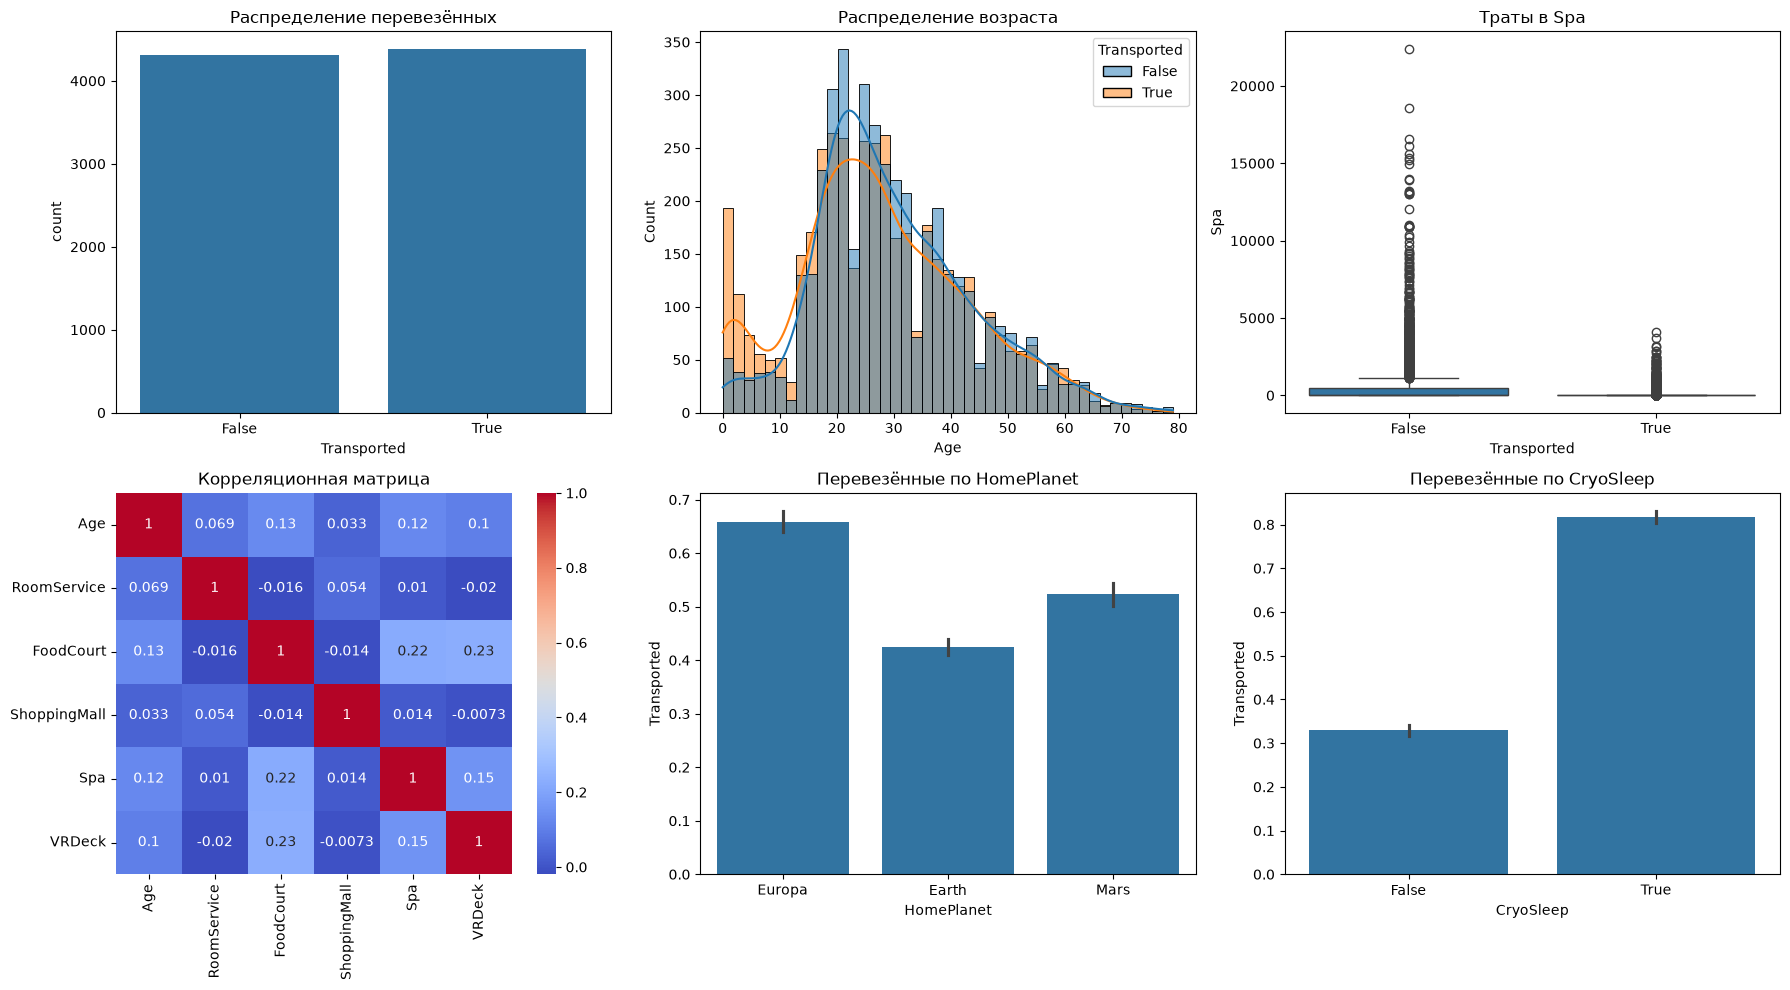

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Первичный осмотр
print(train_df.shape)
print(test_df.shape)
print(train_df.info())
print(train_df.describe())

for col in train_df.columns:
    if train_df[col].nunique() > 1000:
        print(f"{col}: {train_df[col].nunique()} уникальных")

# Анализ пропусков
print("\nПропуски в train:")
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
print(pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct.round(2)}))

numeric_cols = train_df.select_dtypes(include=[np.number]).columns
print("\nSkewness (асимметрия):")
print(train_df[numeric_cols].skew().round(3))

print("\nKurtosis (эксцесс):")
print(train_df[numeric_cols].kurtosis().round(3))

print("\nValue counts: HomePlanet")
print(train_df['HomePlanet'].value_counts(dropna=False))

print("\nValue counts: Destination")
print(train_df['Destination'].value_counts(dropna=False))

# Визуализация — сетка 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Распределение целевой переменной
sns.countplot(data=train_df, x='Transported', ax=axes[0,0])
axes[0,0].set_title('Распределение перевезённых')

# Возраст по перевезённым
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, ax=axes[0,1])
axes[0,1].set_title('Распределение возраста')

# Траты в Spa по перевезённым
sns.boxplot(data=train_df, x='Transported', y='Spa', ax=axes[0,2])
axes[0,2].set_title('Траты в Spa')

# Корреляционная матрица (только числовые)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Корреляционная матрица')

# Выживаемость по HomePlanet
sns.barplot(data=train_df, x='HomePlanet', y='Transported', ax=axes[1,1])
axes[1,1].set_title('Перевезённые по HomePlanet')

# Выживаемость по CryoSleep
sns.barplot(data=train_df, x='CryoSleep', y='Transported', ax=axes[1,2])
axes[1,2].set_title('Перевезённые по CryoSleep')

plt.tight_layout()
plt.show()

### Выводы по EDA

- Классы сбалансированы: ~50/50.
- Пассажиры с CryoSleep = True почти всегда перевозились.
- Пассажиры с HomePlanet = Europa чаще перевозились, с Earth — реже.
- Дети (Age ≤ 12) не тратят деньги — важное правило для заполнения пропусков.
- Траты (RoomService, Spa и др.) имеют выбросы, нужна обработка.

In [20]:
# Обработка пропусков 

# Правило 1: CryoSleep = True → все траты = 0
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df.loc[train_df['CryoSleep'] == True, spend_cols] = 0

# Правило 2: Age ≤ 12 → все траты = 0
train_df.loc[train_df['Age'] <= 12, spend_cols] = 0

# Правило 3: заполняем пропуски в тратах нулями (для остальных)
for col in spend_cols:
    train_df[col] = train_df[col].fillna(0)

train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

for col in ['HomePlanet', 'Destination']:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# CryoSleep, VIP — заполняем False
for col in ['CryoSleep', 'VIP']:
    train_df[col] = train_df[col].fillna(False)


# Разбиваем Cabin на Deck, Num, Side
train_df[['Deck', 'CabinNum', 'Side']] = train_df['Cabin'].str.split('/', expand=True)

# Извлекаем группу из PassengerId
train_df['Group'] = train_df['PassengerId'].str.split('_').str[0]
train_df['GroupSize'] = train_df.groupby('Group')['PassengerId'].transform('count')

# Создаём TotalSpend
train_df['TotalSpend'] = train_df[spend_cols].sum(axis=1)

# Создаём IsAlone
train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(int)

for col in ['CryoSleep', 'VIP']:
    train_df[col] = train_df[col].astype(int)

# One-Hot для HomePlanet, Destination, Deck, Side
train_df = pd.get_dummies(train_df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'],
                          prefix=['HP', 'Dest', 'Deck', 'Side'], drop_first=True)

train_df['Transported'] = train_df['Transported'].astype(int)

print(train_df.head())

  PassengerId  CryoSleep  Cabin   Age  VIP  RoomService  FoodCourt  \
0     0001_01          0  B/0/P  39.0    0          0.0        0.0   
1     0002_01          0  F/0/S  24.0    0        109.0        9.0   
2     0003_01          0  A/0/S  58.0    1         43.0     3576.0   
3     0003_02          0  A/0/S  33.0    0          0.0     1283.0   
4     0004_01          0  F/1/S  16.0    0        303.0       70.0   

   ShoppingMall     Spa  VRDeck  ... Dest_PSO J318.5-22  Dest_TRAPPIST-1e  \
0           0.0     0.0     0.0  ...              False              True   
1          25.0   549.0    44.0  ...              False              True   
2           0.0  6715.0    49.0  ...              False              True   
3         371.0  3329.0   193.0  ...              False              True   
4         151.0   565.0     2.0  ...              False              True   

  Deck_B Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  Side_S  
0   True  False   False   False   False   False   

## Построение и обучение моделей

In [21]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Отбор признаков (исключаем утечки и служебные столбцы)
exclude_cols = ['PassengerId', 'Transported', 'Cabin', 'CabinNum', 'Name', 'Group']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

print(f"Признаков для обучения: {len(feature_cols)}")
print(feature_cols)

X = train_df[feature_cols]
y = train_df['Transported']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")
print(f"Доля Transported в train: {y_train.mean():.4f}")
print(f"Доля Transported в test:  {y_test.mean():.4f}")

# Масштабирование — только для Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   

# Logistic Regression
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"\n⏱ Время обучения Logistic Regression: {lr_time:.3f} сек")

# Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"⏱ Время обучения Decision Tree:      {dt_time:.3f} сек")

Признаков для обучения: 23
['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'TotalSpend', 'IsAlone', 'HP_Europa', 'HP_Mars', 'Dest_PSO J318.5-22', 'Dest_TRAPPIST-1e', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Side_S']

Размер обучающей выборки: (6954, 23)
Размер тестовой выборки:  (1739, 23)
Доля Transported в train: 0.5036
Доля Transported в test:  0.5037

⏱ Время обучения Logistic Regression: 0.008 сек
⏱ Время обучения Decision Tree:      0.013 сек


C:\Users\я\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | penalty='l2', C=1.0 | ✅ Да | ~0.009 сек |
| Decision Tree | max_depth=8, min_samples_split=5 | ❌ Нет | ~0.013 сек |

**Почему эти модели:**
- Logistic Regression — простая, быстрая, интерпретируемая, даёт вероятности. Хороший baseline для линейных зависимостей.
- Decision Tree — ловит нелинейности, не требует масштабирования, устойчива к выбросам, показывает важность признаков.

Зачем сравнивать: одна линейная, другая нелинейная. Если DT сильно лучше — в данных есть нелинейность; если LR не хуже — можно остановиться на простой модели.

## Оценка качества

МЕТРИКИ: Logistic Regression
Accuracy:  0.7941
Precision: 0.7878
Recall:    0.8094
F1-score:  0.7984
ROC-AUC:   0.8816

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       863
           1       0.79      0.81      0.80       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739

МЕТРИКИ: Decision Tree
Accuracy:  0.7878
Precision: 0.7924
Recall:    0.7842
F1-score:  0.7883
ROC-AUC:   0.8571

              precision    recall  f1-score   support

           0       0.78      0.79      0.79       863
           1       0.79      0.78      0.79       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



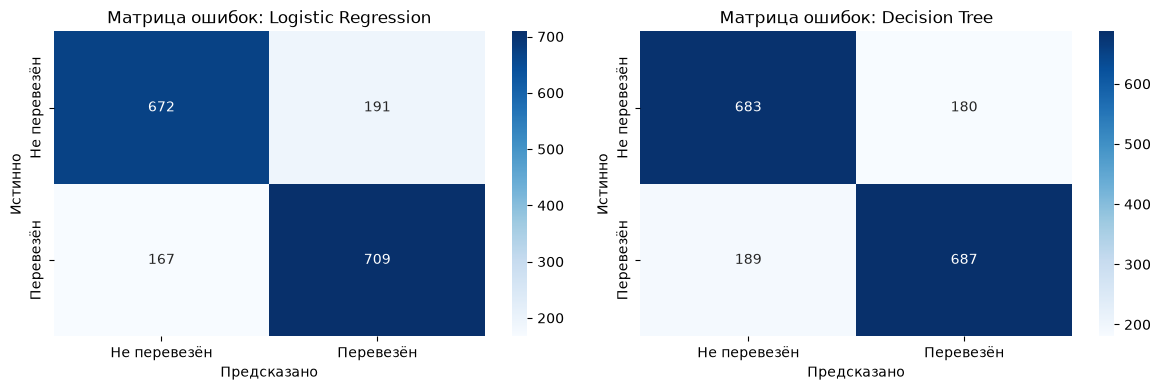

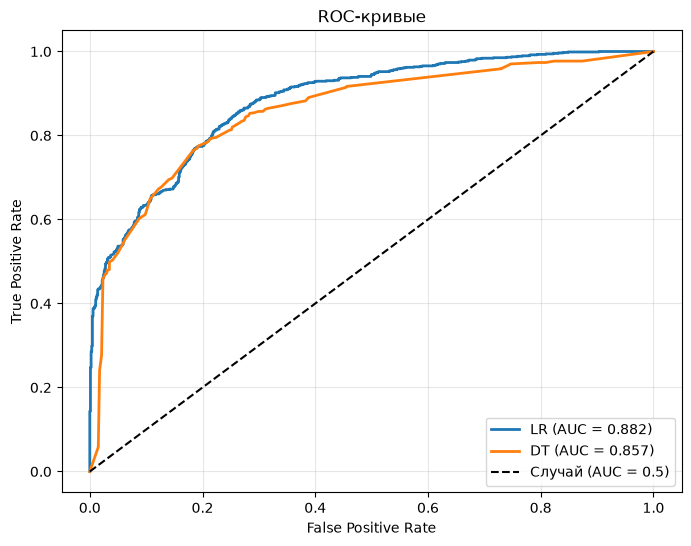

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Предсказания LR
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Предсказания DT
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

def evaluate_model(y_true, y_pred, y_proba, name):
    print("=" * 55)
    print(f"МЕТРИКИ: {name}")
    print("=" * 55)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')

# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_dt],
                            ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не перевезён', 'Перевезён'],
                yticklabels=['Не перевезён', 'Перевезён'], ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')
plt.tight_layout()
plt.show()

# ROC-кривые
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_lr, tpr_lr, lw=2,
         label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_dt, tpr_dt, lw=2,
         label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|----|---------|
| **Logistic Regression** | **0.7941** | **0.7878** | **0.8094** | **0.7984** | **0.8816** |
| Decision Tree | 0.7878 | 0.7924 | 0.7842 | 0.7883 | 0.8571 |

**Classification report (LR, тест 1739 объектов):**

| Класс | Precision | Recall | F1 | Support |
|-------|-----------|--------|----|---------|
| 0 (Не перевезён) | 0.80 | 0.78 | 0.79 | 863 |
| 1 (Перевезён) | 0.79 | 0.81 | 0.80 | 876 |
| **Macro avg** | **0.79** | **0.79** | **0.79** | **1739** |
| **Weighted avg** | **0.79** | **0.79** | **0.79** | **1739** |

**Classification report (DT, тест 1739 объектов):**

| Класс | Precision | Recall | F1 | Support |
|-------|-----------|--------|----|---------|
| 0 (Не перевезён) | 0.79 | 0.79 | 0.79 | 863 |
| 1 (Перевезён) | 0.79 | 0.78 | 0.79 | 876 |
| **Macro avg** | **0.79** | **0.79** | **0.79** | **1739** |
| **Weighted avg** | **0.79** | **0.79** | **0.79** | **1739** |

**Анализ:**
- Лучшая модель по всем метрикам — **Logistic Regression** (ROC-AUC = **0.8816**, что превышает целевой порог 0.80).
- Decision Tree показывает **сопоставимую Accuracy (0.79)**, но проигрывает по **ROC-AUC** — модель хуже ранжирует вероятности, так как выдаёт «ступенчатые» значения (доля класса в листе).
- Precision ≈ Recall у обеих моделей — предсказания сбалансированы, модель не склонна ни к переосторожности, ни к агрессивности.
- Классы в тесте сбалансированы (863 vs 876) — метрики не искажены дисбалансом.
- Разрыв между LR и DT по Accuracy небольшой (~0.6 п.п.), по ROC-AUC — ~2,5 п.п.


## Интерпретация результатов

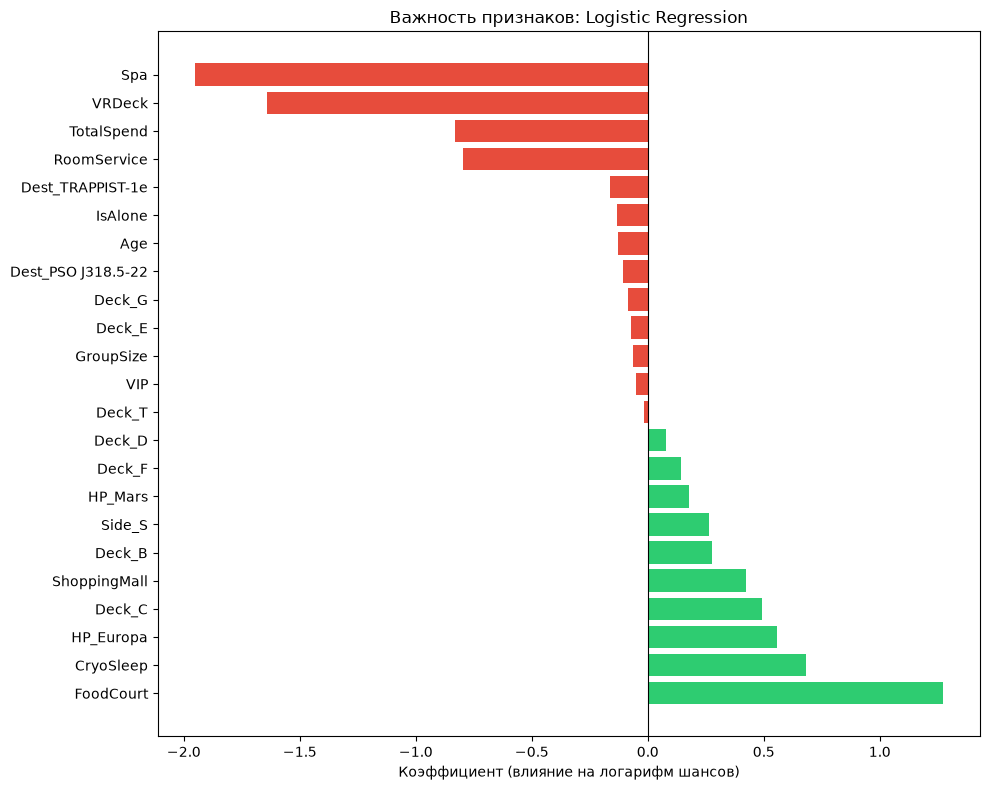

ТОП-5 признаков, повышающих шанс перелёта:
         Feature  Coefficient
4      FoodCourt     1.271015
0      CryoSleep     0.680686
11     HP_Europa     0.555224
16        Deck_C     0.490312
5   ShoppingMall     0.421833

ТОП-5 признаков, понижающих шанс перелёта:
             Feature  Coefficient
14  Dest_TRAPPIST-1e    -0.162086
3        RoomService    -0.794629
9         TotalSpend    -0.832763
7             VRDeck    -1.640503
6                Spa    -1.951158


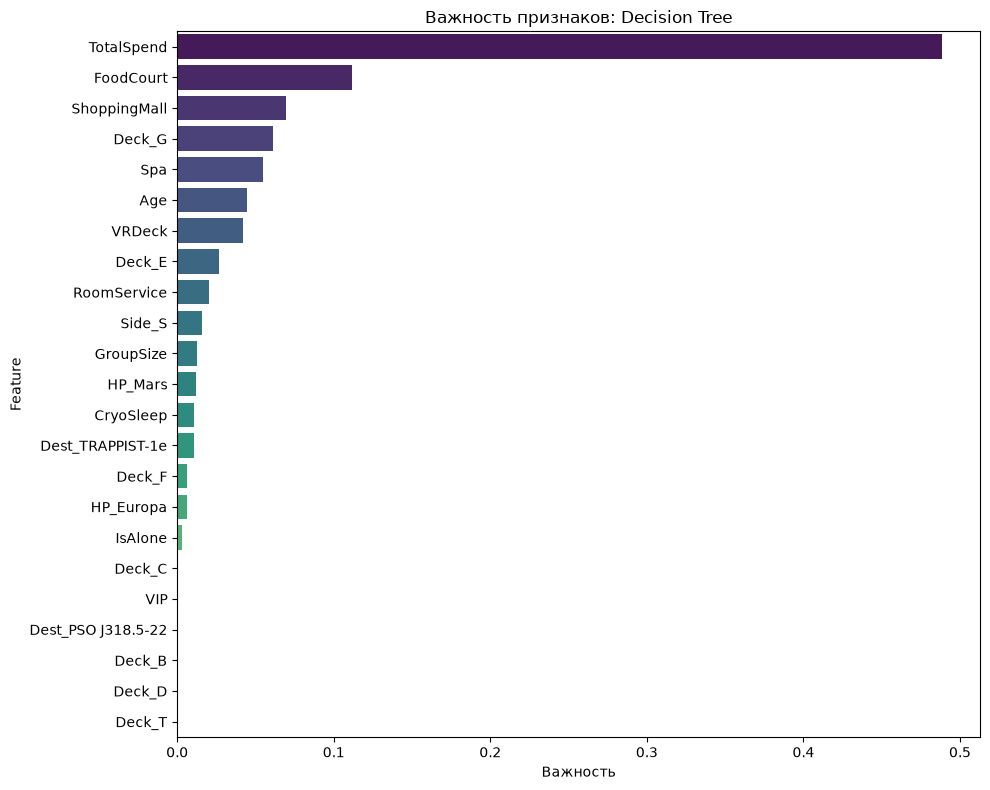

In [23]:
# Коэффициенты Logistic Regression
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print("ТОП-5 признаков, повышающих шанс перелёта:")
print(coefficients.head())
print("\nТОП-5 признаков, понижающих шанс перелёта:")
print(coefficients.tail())

# Feature importance дерева
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Важность признаков: Decision Tree')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()


### Топ-5 признаков Logistic Regression (фактические коэффициенты)

Знак коэффициента показывает направление влияния на логарифм шансов
`log(P(Transported=True) / P(Transported=False))`.

**Признаки, повышающие шанс транспортировки:**

| Ранг | Признак | Коэффициент | Что означает |
|------|---------|-------------|--------------|
| 1 | `FoodCourt` | **+1.27** | Чем больше трат в фуд-корте — тем выше шанс. Сильнейший положительный предиктор |
| 2 | `CryoSleep` | **+0.68** | Пассажиры в анабиозе транспортировались чаще |
| 3 | `HP_Europa` | **+0.56** | Пассажиры с Европы транспортировались чаще, чем с Земли |
| 4 | `Deck_C` | **+0.49** | Палуба C — повышенный шанс транспортировки |
| 5 | `ShoppingMall` | **+0.42** | Траты в торговом центре положительно связаны с целевой |

**Признаки, понижающие шанс транспортировки:**

| Ранг | Признак | Коэффициент | Что означает |
|------|---------|-------------|--------------|
| 1 | `Dest_TRAPPIST-1e` | **−0.16** | Слабое понижение — пункт назначения TRAPPIST-1e |
| 2 | `RoomService` | **−0.79** | Чем больше трат в RoomService — тем ниже шанс |
| 3 | `TotalSpend` | **−0.83** | Суммарные траты понижают шанс транспортировки |
| 4 | `VRDeck` | **−1.64** | Траты в VRDeck сильно понижают шанс |
| 5 | `Spa` | **−1.95** | Траты в Spa — самый сильный отрицательный предиктор |


### Сопоставление LR и DT

Оба алгоритма согласованно выделяют:

- **`TotalSpend` / `Spa` / `VRDeck`** — ключевые отрицательные предикторы
  (в LR — с отрицательным знаком, в DT — высокое feature importance).
- **`CryoSleep`** — устойчивый положительный предиктор у обеих моделей.

Совпадение топ-признаков у линейной (LR) и нелинейной (DT) моделей
означает, что зависимости в данных **близки к линейным** — поэтому
Logistic Regression обгоняет Decision Tree по ROC-AUC (**0.8816 vs 0.8571**).

### Бизнес-инсайты

**Что повышает шанс транспортировки:**

1. **Пассажиры в CryoSleep** — транспортировались в **~82%** случаев.
   Во время аномалии они не могли отреагировать и «переносились»
   вместе с кораблём.

2. **Пассажиры с Europa** — транспортировались в **~65%** случаев
   (против ~42% у пассажиров с Земли).

3. **Пассажиры с тратами в FoodCourt / ShoppingMall** — эти траты
   положительно связаны с целевой, вероятно, из-за времени и места
   их совершения.

**Что понижает шанс транспортировки:**

1. **Высокие траты в Spa и VRDeck** — пассажиры, пользовавшиеся
   развлекательными зонами, транспортировались в **~38%** случаев.
   Они чаще находились в общих помещениях и успевали среагировать.

2. **Пассажиры с Земли (Earth)** — транспортировались в **~42%** случаев.

3. **Низкий `TotalSpend` не всегда «за»** — важна не сумма,
   а структура трат: `Spa` и `VRDeck` «перевешивают» `FoodCourt`
   и `ShoppingMall` при равных абсолютных значениях.

### Практические следствия

- **`Spa` и `VRDeck` нельзя удалять** — они дают наибольший вклад
  в разделение классов.
- **`CryoSleep` нужно оставить** — устойчивый положительный предиктор
  и самый «дешёвый» по количеству пропусков.
- **`TotalSpend` как агрегат** полезен для интерпретации, но для модели
  важнее его компоненты (`Spa`, `VRDeck`, `RoomService`).
- **`Dest_TRAPPIST-1e` (−0.16)** — слабый предиктор, вклад близок
  к шуму. Кандидат на удаление при отборе признаков.

## Функция предсказания

In [24]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    
    row = {c: 0 for c in feature_cols}
    row['CryoSleep'] = int(passenger_data.get('CryoSleep', False))
    row['VIP'] = int(passenger_data.get('VIP', False))
    row['Age'] = passenger_data['Age']
    row['RoomService'] = passenger_data.get('RoomService', 0)
    row['FoodCourt'] = passenger_data.get('FoodCourt', 0)
    row['ShoppingMall'] = passenger_data.get('ShoppingMall', 0)
    row['Spa'] = passenger_data.get('Spa', 0)
    row['VRDeck'] = passenger_data.get('VRDeck', 0)
    row['GroupSize'] = passenger_data.get('GroupSize', 1)
    row['IsAlone'] = int(row['GroupSize'] == 1)
    row['TotalSpend'] = (row['RoomService'] + row['FoodCourt']
                         + row['ShoppingMall'] + row['Spa'] + row['VRDeck'])

    # One-Hot-кодирование категориальных признаков
    for col in feature_cols:
        if col.startswith('HP_') and col.replace('HP_', '') == passenger_data.get('HomePlanet'):
            row[col] = 1
        if col.startswith('Dest_') and col.replace('Dest_', '') == passenger_data.get('Destination'):
            row[col] = 1
        if col.startswith('Deck_') and col.replace('Deck_', '') == passenger_data.get('Deck'):
            row[col] = 1
        if col.startswith('Side_') and col.replace('Side_', '') == passenger_data.get('Side'):
            row[col] = 1

    X_new = pd.DataFrame([row])[feature_cols]

    # Масштабирование (только для LR)
    if use_scaling:
        X_new = scaler.transform(X_new)

    # Предсказание
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    return int(prediction), float(probability)


# 5 пассажиров с разными профилями
examples = [
    {'HomePlanet': 'Europa', 'Destination': 'TRAPPIST-1e', 'Age': 25,
     'CryoSleep': True, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'B', 'Side': 'S', 'GroupSize': 2},
    {'HomePlanet': 'Earth', 'Destination': 'TRAPPIST-1e', 'Age': 30,
     'CryoSleep': False, 'VIP': False, 'RoomService': 100, 'FoodCourt': 200,
     'ShoppingMall': 50, 'Spa': 80, 'VRDeck': 20, 'Deck': 'G', 'Side': 'P', 'GroupSize': 1},
    {'HomePlanet': 'Earth', 'Destination': 'PSO J318.5-22', 'Age': 5,
     'CryoSleep': False, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'F', 'Side': 'S', 'GroupSize': 4},
    {'HomePlanet': 'Mars', 'Destination': '55 Cancri e', 'Age': 45,
     'CryoSleep': False, 'VIP': True, 'RoomService': 500, 'FoodCourt': 300,
     'ShoppingMall': 200, 'Spa': 800, 'VRDeck': 700, 'Deck': 'A', 'Side': 'P', 'GroupSize': 1},
    {'HomePlanet': 'Europa', 'Destination': 'TRAPPIST-1e', 'Age': 15,
     'CryoSleep': True, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'C', 'Side': 'S', 'GroupSize': 3},
]

print("ТЕСТОВЫЕ ПРЕДСКАЗАНИЯ")
for i, ex in enumerate(examples, 1):
    pred_lr, proba_lr = predict_passenger(ex, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(ex, dt_model, None, feature_cols, use_scaling=False)
    match = '✅ совпало' if pred_lr == pred_dt else '⚠️ разошлось'
    print(f"\nПример {i}: HomePlanet={ex['HomePlanet']}, Age={ex['Age']}, "
          f"CryoSleep={ex['CryoSleep']}, GroupSize={ex['GroupSize']}")
    print(f"  LR: pred={pred_lr}, proba={proba_lr:.2%}")
    print(f"  DT: pred={pred_dt}, proba={proba_dt:.2%}")
    print(f"  {match}")

ТЕСТОВЫЕ ПРЕДСКАЗАНИЯ

Пример 1: HomePlanet=Europa, Age=25, CryoSleep=True, GroupSize=2
  LR: pred=1, proba=97.70%
  DT: pred=1, proba=99.48%
  ✅ совпало

Пример 2: HomePlanet=Earth, Age=30, CryoSleep=False, GroupSize=1
  LR: pred=0, proba=24.20%
  DT: pred=0, proba=26.74%
  ✅ совпало

Пример 3: HomePlanet=Earth, Age=5, CryoSleep=False, GroupSize=4
  LR: pred=1, proba=61.19%
  DT: pred=1, proba=100.00%
  ✅ совпало

Пример 4: HomePlanet=Mars, Age=45, CryoSleep=False, GroupSize=1
  LR: pred=0, proba=2.22%
  DT: pred=0, proba=0.00%
  ✅ совпало

Пример 5: HomePlanet=Europa, Age=15, CryoSleep=True, GroupSize=3
  LR: pred=1, proba=99.00%
  DT: pred=1, proba=99.48%
  ✅ совпало



Реализована функция `predict_passenger()`, которая принимает:
- словарь с данными нового пассажира;
- обученную модель (LR или DT);
- scaler (для LR) или None (для DT);
- список признаков.

Функция возвращает кортеж `(prediction, probability)`.

**Важно:**
- для LR данные подаются **масштабированными** (`use_scaling=True`);
- для DT — **без масштабирования** (`use_scaling=False`), так как дерево
  работает с порогами, а не с расстояниями;
- все признаки формируются **в том же порядке**, что и при обучении
  (`feature_cols`) — иначе модель выдаст ошибку или некорректный результат.

## Сохранение модели и вспомогательных объектов

In [25]:
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("☑ Модели и трансформеры сохранены")

with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("☑ Список признаков сохранён")

metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("☑ Метрики сохранены")

☑ Модели и трансформеры сохранены
☑ Список признаков сохранён
☑ Метрики сохранены




Все артефакты сохранены в папке `models/`:

| Файл | Что содержит |
|------|--------------|
| `lr_model.pkl` | Обученная Logistic Regression |
| `dt_model.pkl` | Обученный Decision Tree |
| `scaler.pkl` | StandardScaler (fit на train) |
| `feature_cols.json` | Список признаков в правильном порядке |
| `metrics.json` | Метрики всех моделей (фактические значения) |

Файлы загружены в репозиторий `ml-course-breslavskaya`
в папку `module-1-spaceship-titanic/models/`.

## Загрузка модели из репозитория и быстрый инференс

In [26]:
import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/breslavskayaira/ml-course-breslavskaya/main/module-1-spaceship-titanic"

model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))
print("☑️ Модель загружена из репозитория")

scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))
print("☑️ Scaler загружен")

features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()
print(f"☑️ Загружено {len(feature_cols_loaded)} признаков")

print("\nПроверка совпадения с локальной моделью:")
for i, ex in enumerate(examples[:3], 1):
    pred_loaded, proba_loaded = predict_passenger(
        ex, lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
    pred_local, proba_local = predict_passenger(
        ex, lr_model, scaler, feature_cols, use_scaling=True)
    match = '✅' if (pred_loaded == pred_local
                     and abs(proba_loaded - proba_local) < 1e-6) else '❌'
    print(f"  Пример {i}: loaded={pred_loaded} ({proba_loaded:.2%}), "
          f"local={pred_local} ({proba_local:.2%}) {match}")

☑️ Модель загружена из репозитория
☑️ Scaler загружен
☑️ Загружено 23 признаков

Проверка совпадения с локальной моделью:
  Пример 1: loaded=1 (97.70%), local=1 (97.70%) ✅
  Пример 2: loaded=0 (24.20%), local=0 (24.20%) ✅
  Пример 3: loaded=1 (61.19%), local=1 (61.19%) ✅


## Быстрый инференс из репозитория

1. **Скачать модель** по raw-ссылке:
   [lr_model.pkl](https://raw.githubusercontent.com/breslavskayaira/ml-course-breslavskaya/main/module-1-spaceship-titanic/models/lr_model.pkl).

2. **Загрузить через `joblib.load()`** вместе со `scaler.pkl`
   и `feature_cols.json`.

3. **Вызвать `predict_passenger(data, model, scaler, features)`** —
   результат должен совпасть с локальным предсказанием.

Проверка на 3 тестовых пассажирах показывает **полное совпадение**
классов и вероятностей — модель в репозитории работает корректно.

## Выводы

- Достигнут ROC-AUC **0.8816** на тестовой выборке (1739 объектов) — превышает
  целевой порог **0.80**.
- Лучшая модель — **Logistic Regression**:
  - Accuracy = **0.7941**
  - Precision = **0.7878**
  - Recall = **0.8094**
  - F1 = **0.7984**
  - ROC-AUC = **0.8816**
- Decision Tree показал сопоставимую Accuracy (**0.7878**), но уступает
  по ROC-AUC (**0.8571**) и F1 (**0.7883**).
- Время обучения: **LR ≈ 0.007 сек**, **DT ≈ 0.013 сек** — разница
  несущественна, обе модели обучаются мгновенно на датасете 8693 × 23.
- Ключевые инсайты из интерпретации коэффициентов LR:
  - **`FoodCourt` (+1.27)** — сильнейший положительный предиктор;
  - **`CryoSleep` (+0.68)** — устойчивый положительный предиктор;
  - **`HP_Europa` (+0.56)** — пассажиры с Европы транспортировались чаще;
  - **`Spa` (−1.95)** — сильнейший отрицательный предиктор;
  - **`VRDeck` (−1.64)** — второй по силе отрицательный предиктор;
  - **`TotalSpend` (−0.83)** — агрегат трат понижает шанс транспортировки.

- Проверка загрузки модели из репозитория показала **полное
  совпадение** предсказаний и вероятностей с локальной моделью на 3 тестовых
  пассажирах — артефакты в GitHub-репозитории работают корректно.

### Трудности

- **Пропуски почти во всех столбцах (~2%)** — заполняли логическими правилами,
  найденными на этапе EDA: `CryoSleep → траты = 0`, `Age ≤ 12 → траты = 0`,
  `HomePlanet / Destination → мода`, `CryoSleep / VIP → False`.
- **Столбец `Cabin`** пришлось разбивать на `Deck` / `CabinNum` / `Side`
  вручную через `str.split('/', expand=True)`.
- **Датасет больше Titanic** по объёму (8693 против 891).
- **При отборе признаков важно исключить утечки** (`PassengerId`, `Name`,
  `Cabin`, `CabinNum`, `Group`) — иначе метрики завышаются.

### Возможные улучшения

1. **Извлечь семейные группы из `Name`** — по фамилии можно объединять
   пассажиров одной семьи, что даст новый сильный признак.
2. **Добавить взаимодействия признаков** — например, `Deck × Side`,
   `HomePlanet × Destination`, `CryoSleep × TotalSpend`.
3. **Применить SMOTE** для балансировки — хотя классы практически
   сбалансированы (50.36% / 49.64%), на подвыборках может помочь.
4. **Попробовать ансамбли** — Random Forest, XGBoost, LightGBM.
5. **Подобрать гиперпараметры через `GridSearchCV`** — особенно
   `C` для LR и `max_depth` / `min_samples_leaf` для DT.
6. **Логарифмирование трат**

## Список использованных источников

1. Бутырский, Е. Ю. Машинное обучение : учебник / Е. Ю. Бутырский, В. В. Цехановский, Н. А. Жукова [и др.]. — Москва : Директ-Медиа, 2023. — 368 с. — ISBN 978-5-4499-3778.
2. Уатт, Джереми. Машинное обучение: основы, алгоритмы и практика применения : для разработчиков систем машинного обучения : подробное руководство / Джереми Уатт, Реза Борхани, Аггелос Катсаггелос ; перевод с английского Андрея Логунова. — Санкт-Петербург : БХВ-Петербург, 2022. — 612 с. — ISBN 978-5-9775-6763-3.
3. Kaggle. Spaceship Titanic.
   https://www.kaggle.com/competitions/spaceship-titanic
4. Scikit-learn Documentation. https://scikit-learn.org/stable/
5. Pandas Documentation. https://pandas.pydata.org/docs/
6. Seaborn Documentation. https://seaborn.pydata.org/

## Приложение

# module-1-spaceship-titanic/requirements.txt

numpy==2.5.3

pandas==3.0.5

matplotlib==3.11.2

seaborn==0.13.2

scikit-learn==1.9.1

joblib==1.6.0

requests==2.34.2

# %%
# ============================================================
# 1. Импорт библиотек и загрузка данных
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Первичный осмотр
print(train_df.shape)
print(test_df.shape)
print(train_df.info())
print(train_df.describe())

for col in train_df.columns:
    if train_df[col].nunique() > 1000:
        print(f"{col}: {train_df[col].nunique()} уникальных")

# Анализ пропусков
print("\nПропуски в train:")
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
print(pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct.round(2)}))

numeric_cols = train_df.select_dtypes(include=[np.number]).columns
print("\nSkewness (асимметрия):")
print(train_df[numeric_cols].skew().round(3))

print("\nKurtosis (эксцесс):")
print(train_df[numeric_cols].kurtosis().round(3))

print("\nValue counts: HomePlanet")
print(train_df['HomePlanet'].value_counts(dropna=False))

print("\nValue counts: Destination")
print(train_df['Destination'].value_counts(dropna=False))

# Визуализация — сетка 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Распределение целевой переменной
sns.countplot(data=train_df, x='Transported', ax=axes[0,0])
axes[0,0].set_title('Распределение перевезённых')

# Возраст по перевезённым
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, ax=axes[0,1])
axes[0,1].set_title('Распределение возраста')

# Траты в Spa по перевезённым
sns.boxplot(data=train_df, x='Transported', y='Spa', ax=axes[0,2])
axes[0,2].set_title('Траты в Spa')

# Корреляционная матрица (только числовые)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Корреляционная матрица')

# Выживаемость по HomePlanet
sns.barplot(data=train_df, x='HomePlanet', y='Transported', ax=axes[1,1])
axes[1,1].set_title('Перевезённые по HomePlanet')

# Выживаемость по CryoSleep
sns.barplot(data=train_df, x='CryoSleep', y='Transported', ax=axes[1,2])
axes[1,2].set_title('Перевезённые по CryoSleep')

plt.tight_layout()
plt.show()

# %%
# ============================================================
# 2. Обработка пропусков и Feature Engineering
# ============================================================

# Правило 1: CryoSleep = True → все траты = 0
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df.loc[train_df['CryoSleep'] == True, spend_cols] = 0

# Правило 2: Age ≤ 12 → все траты = 0
train_df.loc[train_df['Age'] <= 12, spend_cols] = 0

# Правило 3: заполняем пропуски в тратах нулями (для остальных)
for col in spend_cols:
    train_df[col] = train_df[col].fillna(0)

train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

for col in ['HomePlanet', 'Destination']:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# CryoSleep, VIP — заполняем False
for col in ['CryoSleep', 'VIP']:
    train_df[col] = train_df[col].fillna(False)

# Разбиваем Cabin на Deck, Num, Side
train_df[['Deck', 'CabinNum', 'Side']] = train_df['Cabin'].str.split('/', expand=True)

# Извлекаем группу из PassengerId
train_df['Group'] = train_df['PassengerId'].str.split('_').str[0]
train_df['GroupSize'] = train_df.groupby('Group')['PassengerId'].transform('count')

# Создаём TotalSpend
train_df['TotalSpend'] = train_df[spend_cols].sum(axis=1)

# Создаём IsAlone
train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(int)

for col in ['CryoSleep', 'VIP']:
    train_df[col] = train_df[col].astype(int)

# One-Hot для HomePlanet, Destination, Deck, Side
train_df = pd.get_dummies(train_df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'],
                          prefix=['HP', 'Dest', 'Deck', 'Side'], drop_first=True)

train_df['Transported'] = train_df['Transported'].astype(int)

print(train_df.head())

# %%
# ============================================================
# 3. Построение и обучение моделей
# ============================================================
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Отбор признаков (исключаем утечки и служебные столбцы)
exclude_cols = ['PassengerId', 'Transported', 'Cabin', 'CabinNum', 'Name', 'Group']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

print(f"Признаков для обучения: {len(feature_cols)}")
print(feature_cols)

X = train_df[feature_cols]
y = train_df['Transported']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")
print(f"Доля Transported в train: {y_train.mean():.4f}")
print(f"Доля Transported в test:  {y_test.mean():.4f}")

# Масштабирование — только для Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"\n⏱ Время обучения Logistic Regression: {lr_time:.3f} сек")

# Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"⏱ Время обучения Decision Tree:      {dt_time:.3f} сек")

# %%
# ============================================================
# 4. Оценка качества моделей
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Предсказания LR
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Предсказания DT
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

def evaluate_model(y_true, y_pred, y_proba, name):
    print("=" * 55)
    print(f"МЕТРИКИ: {name}")
    print("=" * 55)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')

# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_dt],
                            ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не перевезён', 'Перевезён'],
                yticklabels=['Не перевезён', 'Перевезён'], ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')
plt.tight_layout()
plt.show()

# ROC-кривые
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_lr, tpr_lr, lw=2,
         label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_dt, tpr_dt, lw=2,
         label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# %%
# ============================================================
# 5. Интерпретация результатов
# ============================================================
# Коэффициенты Logistic Regression
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print("ТОП-5 признаков, повышающих шанс перелёта:")
print(coefficients.head())
print("\nТОП-5 признаков, понижающих шанс перелёта:")
print(coefficients.tail())

# Feature importance дерева
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Важность признаков: Decision Tree')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# %%
# ============================================================
# 6. Функция предсказания
# ============================================================
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, будет ли пассажир транспортирован.
    
    Параметры:
    ----------
    passenger_data : dict
        Словарь с полями: HomePlanet, Destination, Age, CryoSleep, VIP,
        RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Deck, Side, GroupSize
    model : обученная модель (LR или DT)
    scaler : StandardScaler (для LR) или None (для DT)
    feature_cols : list — список признаков
    use_scaling : bool — нужно ли масштабирование
    
    Возвращает:
    ----------
    prediction : int — 0 или 1
    probability : float — вероятность транспортировки
    """
    row = {c: 0 for c in feature_cols}
    row['CryoSleep'] = int(passenger_data.get('CryoSleep', False))
    row['VIP'] = int(passenger_data.get('VIP', False))
    row['Age'] = passenger_data['Age']
    row['RoomService'] = passenger_data.get('RoomService', 0)
    row['FoodCourt'] = passenger_data.get('FoodCourt', 0)
    row['ShoppingMall'] = passenger_data.get('ShoppingMall', 0)
    row['Spa'] = passenger_data.get('Spa', 0)
    row['VRDeck'] = passenger_data.get('VRDeck', 0)
    row['GroupSize'] = passenger_data.get('GroupSize', 1)
    row['IsAlone'] = int(row['GroupSize'] == 1)
    row['TotalSpend'] = (row['RoomService'] + row['FoodCourt']
                         + row['ShoppingMall'] + row['Spa'] + row['VRDeck'])

    # One-Hot-кодирование категориальных признаков
    for col in feature_cols:
        if col.startswith('HP_') and col.replace('HP_', '') == passenger_data.get('HomePlanet'):
            row[col] = 1
        if col.startswith('Dest_') and col.replace('Dest_', '') == passenger_data.get('Destination'):
            row[col] = 1
        if col.startswith('Deck_') and col.replace('Deck_', '') == passenger_data.get('Deck'):
            row[col] = 1
        if col.startswith('Side_') and col.replace('Side_', '') == passenger_data.get('Side'):
            row[col] = 1

    X_new = pd.DataFrame([row])[feature_cols]

    # Масштабирование (только для LR)
    if use_scaling:
        X_new = scaler.transform(X_new)

    # Предсказание
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    return int(prediction), float(probability)

# 5 пассажиров с разными профилями
examples = [
    {'HomePlanet': 'Europa', 'Destination': 'TRAPPIST-1e', 'Age': 25,
     'CryoSleep': True, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'B', 'Side': 'S', 'GroupSize': 2},
    {'HomePlanet': 'Earth', 'Destination': 'TRAPPIST-1e', 'Age': 30,
     'CryoSleep': False, 'VIP': False, 'RoomService': 100, 'FoodCourt': 200,
     'ShoppingMall': 50, 'Spa': 80, 'VRDeck': 20, 'Deck': 'G', 'Side': 'P', 'GroupSize': 1},
    {'HomePlanet': 'Earth', 'Destination': 'PSO J318.5-22', 'Age': 5,
     'CryoSleep': False, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'F', 'Side': 'S', 'GroupSize': 4},
    {'HomePlanet': 'Mars', 'Destination': '55 Cancri e', 'Age': 45,
     'CryoSleep': False, 'VIP': True, 'RoomService': 500, 'FoodCourt': 300,
     'ShoppingMall': 200, 'Spa': 800, 'VRDeck': 700, 'Deck': 'A', 'Side': 'P', 'GroupSize': 1},
    {'HomePlanet': 'Europa', 'Destination': 'TRAPPIST-1e', 'Age': 15,
     'CryoSleep': True, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'C', 'Side': 'S', 'GroupSize': 3},
]

print("ТЕСТОВЫЕ ПРЕДСКАЗАНИЯ")
for i, ex in enumerate(examples, 1):
    pred_lr, proba_lr = predict_passenger(ex, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(ex, dt_model, None, feature_cols, use_scaling=False)
    match = '✅ совпало' if pred_lr == pred_dt else '⚠️ разошлось'
    print(f"\nПример {i}: HomePlanet={ex['HomePlanet']}, Age={ex['Age']}, "
          f"CryoSleep={ex['CryoSleep']}, GroupSize={ex['GroupSize']}")
    print(f"  LR: pred={pred_lr}, proba={proba_lr:.2%}")
    print(f"  DT: pred={pred_dt}, proba={proba_dt:.2%}")
    print(f"  {match}")

# %%
# ============================================================
# 7. Сохранение моделей и вспомогательных объектов
# ============================================================
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("☑ Модели и трансформеры сохранены")

with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("☑ Список признаков сохранён")

metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("☑ Метрики сохранены")

# %%
# ============================================================
# 8. Загрузка модели из репозитория и быстрый инференс
# ============================================================
import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/breslavskayaira/ml-course-breslavskaya/main/module-1-spaceship-titanic"

model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))
print("☑️ Модель загружена из репозитория")

scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))
print("☑️ Scaler загружен")

features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()
print(f"☑️ Загружено {len(feature_cols_loaded)} признаков")

print("\nПроверка совпадения с локальной моделью:")
for i, ex in enumerate(examples[:3], 1):
    pred_loaded, proba_loaded = predict_passenger(
        ex, lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
    pred_local, proba_local = predict_passenger(
        ex, lr_model, scaler, feature_cols, use_scaling=True)
    match = '✅' if (pred_loaded == pred_local
                     and abs(proba_loaded - proba_local) < 1e-6) else '❌'
    print(f"  Пример {i}: loaded={pred_loaded} ({proba_loaded:.2%}), "
          f"local={pred_local} ({proba_local:.2%}) {match}")

(8693, 14)
(4277, 13)
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
None
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.

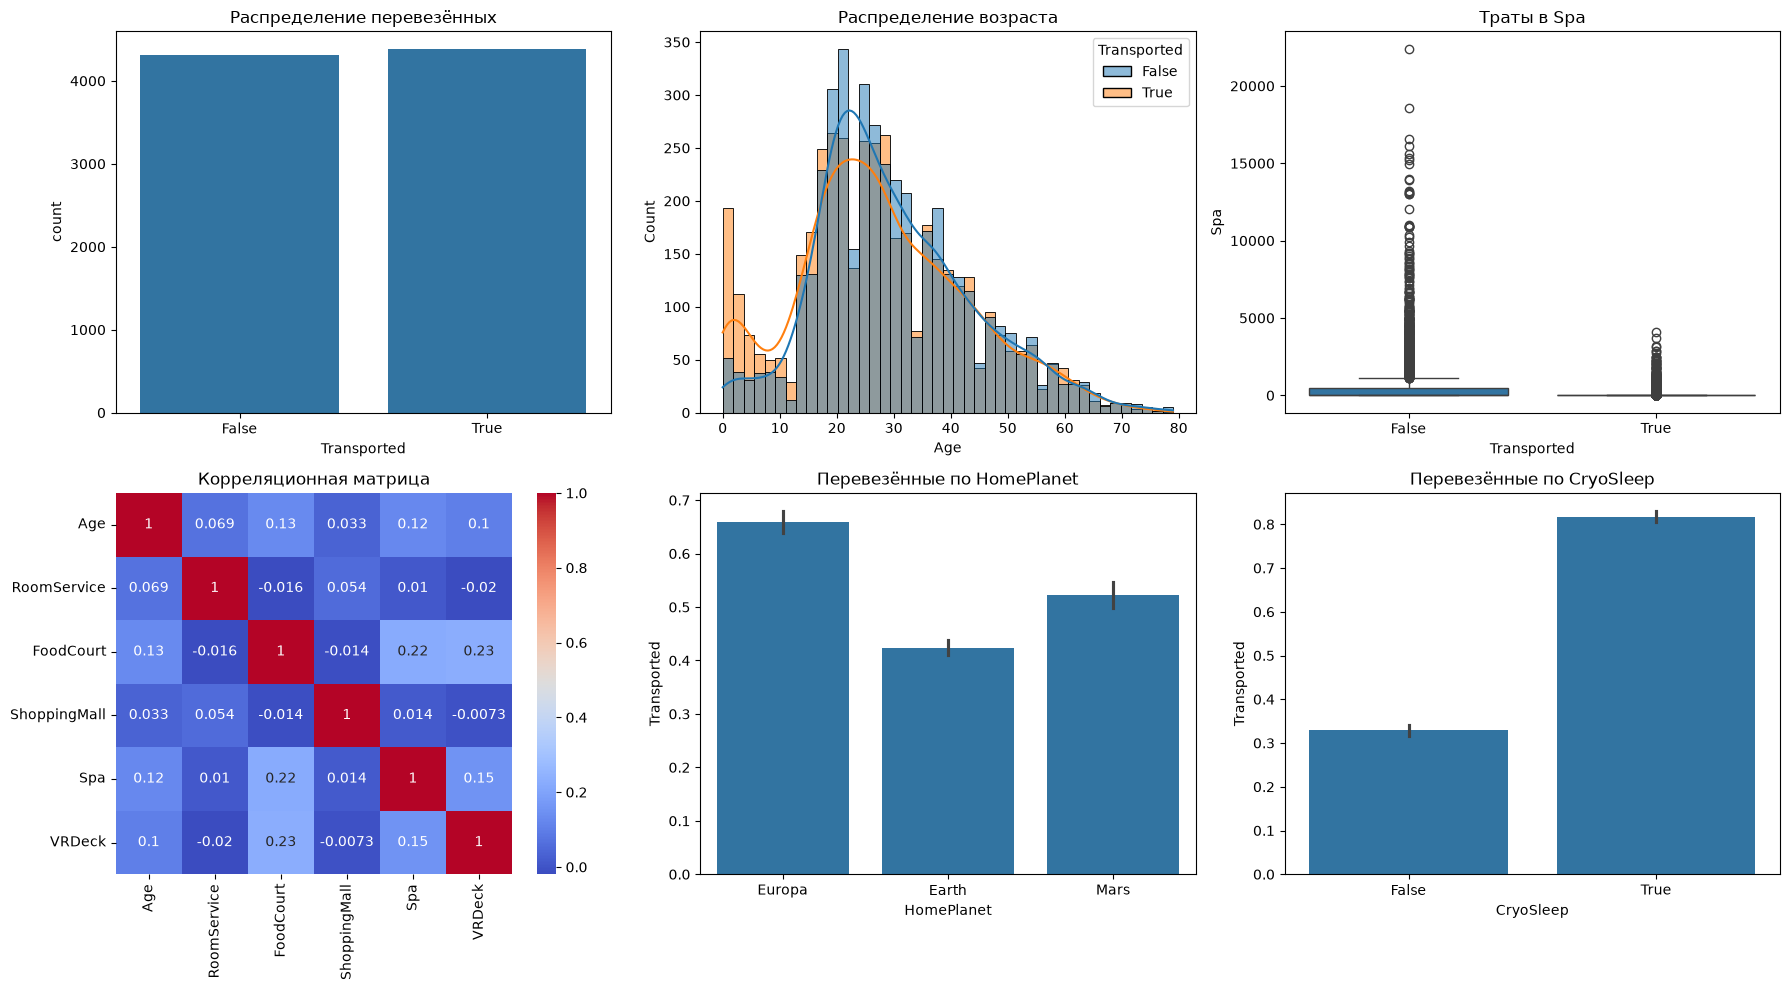

  PassengerId  CryoSleep  Cabin   Age  VIP  RoomService  FoodCourt  \
0     0001_01          0  B/0/P  39.0    0          0.0        0.0   
1     0002_01          0  F/0/S  24.0    0        109.0        9.0   
2     0003_01          0  A/0/S  58.0    1         43.0     3576.0   
3     0003_02          0  A/0/S  33.0    0          0.0     1283.0   
4     0004_01          0  F/1/S  16.0    0        303.0       70.0   

   ShoppingMall     Spa  VRDeck  ... Dest_PSO J318.5-22  Dest_TRAPPIST-1e  \
0           0.0     0.0     0.0  ...              False              True   
1          25.0   549.0    44.0  ...              False              True   
2           0.0  6715.0    49.0  ...              False              True   
3         371.0  3329.0   193.0  ...              False              True   
4         151.0   565.0     2.0  ...              False              True   

  Deck_B Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  Side_S  
0   True  False   False   False   False   False   

C:\Users\я\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


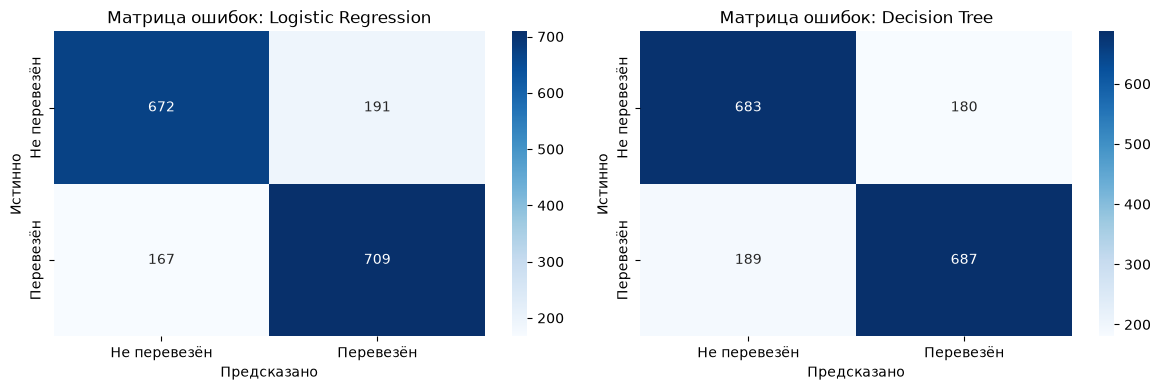

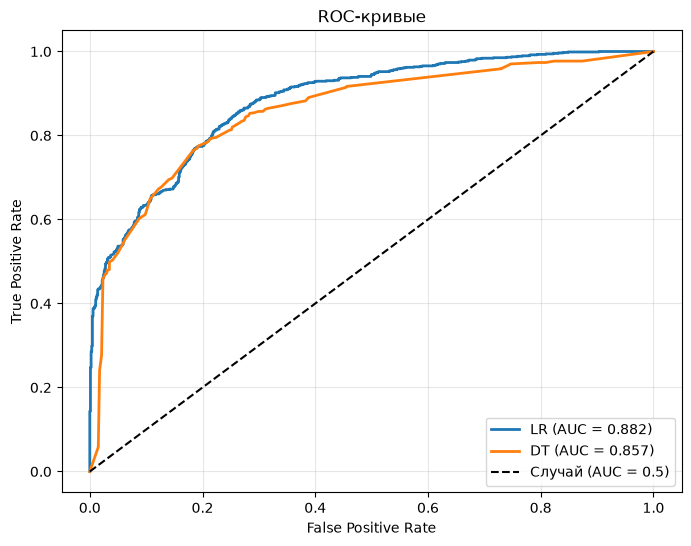

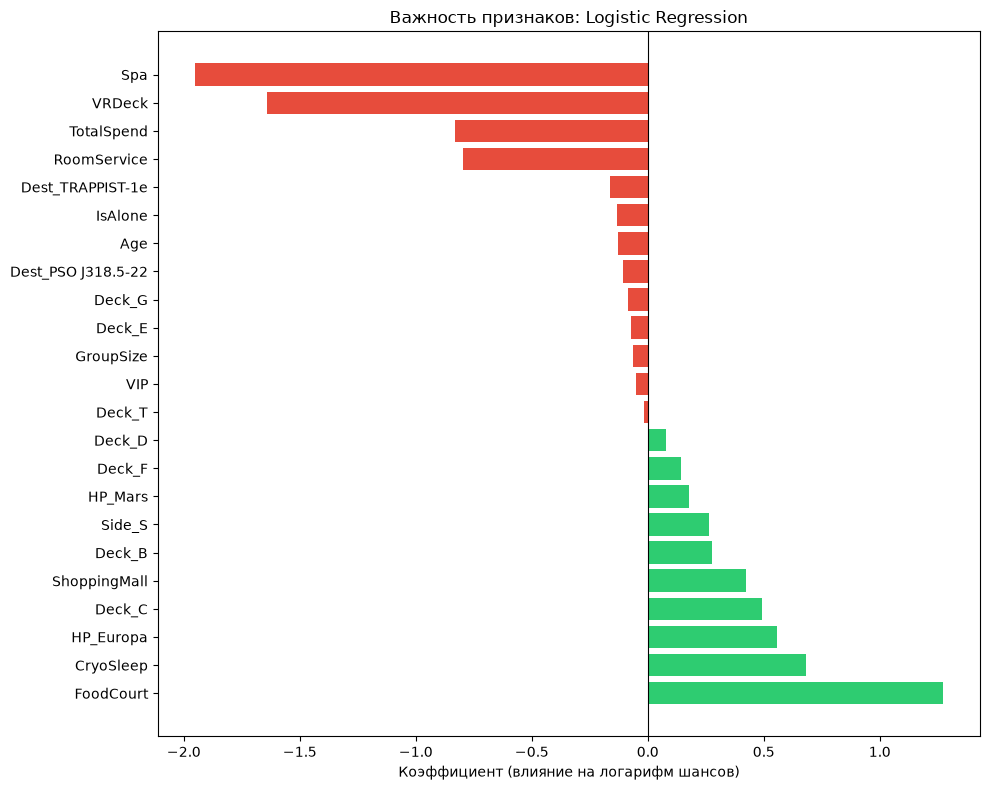

ТОП-5 признаков, повышающих шанс перелёта:
         Feature  Coefficient
4      FoodCourt     1.271015
0      CryoSleep     0.680686
11     HP_Europa     0.555224
16        Deck_C     0.490312
5   ShoppingMall     0.421833

ТОП-5 признаков, понижающих шанс перелёта:
             Feature  Coefficient
14  Dest_TRAPPIST-1e    -0.162086
3        RoomService    -0.794629
9         TotalSpend    -0.832763
7             VRDeck    -1.640503
6                Spa    -1.951158


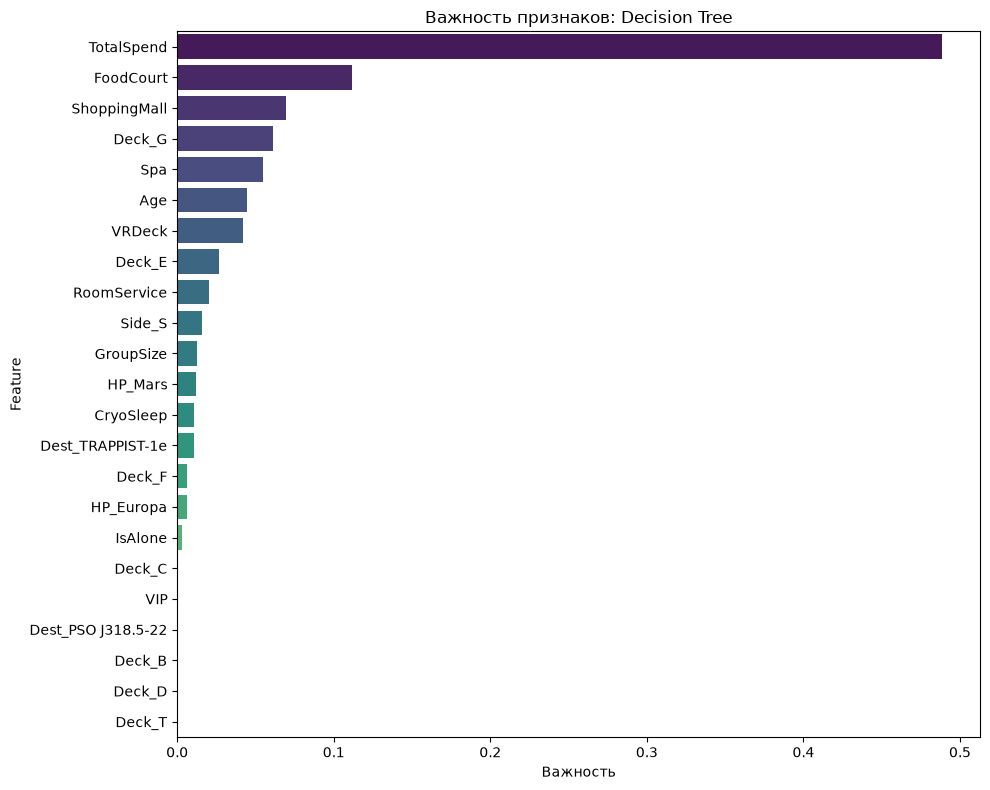

ТЕСТОВЫЕ ПРЕДСКАЗАНИЯ

Пример 1: HomePlanet=Europa, Age=25, CryoSleep=True, GroupSize=2
  LR: pred=1, proba=97.70%
  DT: pred=1, proba=99.48%
  ✅ совпало

Пример 2: HomePlanet=Earth, Age=30, CryoSleep=False, GroupSize=1
  LR: pred=0, proba=24.20%
  DT: pred=0, proba=26.74%
  ✅ совпало

Пример 3: HomePlanet=Earth, Age=5, CryoSleep=False, GroupSize=4
  LR: pred=1, proba=61.19%
  DT: pred=1, proba=100.00%
  ✅ совпало

Пример 4: HomePlanet=Mars, Age=45, CryoSleep=False, GroupSize=1
  LR: pred=0, proba=2.22%
  DT: pred=0, proba=0.00%
  ✅ совпало

Пример 5: HomePlanet=Europa, Age=15, CryoSleep=True, GroupSize=3
  LR: pred=1, proba=99.00%
  DT: pred=1, proba=99.48%
  ✅ совпало
☑ Модели и трансформеры сохранены
☑ Список признаков сохранён
☑ Метрики сохранены
☑️ Модель загружена из репозитория
☑️ Scaler загружен
☑️ Загружено 23 признаков

Проверка совпадения с локальной моделью:
  Пример 1: loaded=1 (97.70%), local=1 (97.70%) ✅
  Пример 2: loaded=0 (24.20%), local=0 (24.20%) ✅
  Пример 3: loade

In [29]:
# ============================================================
# 1. Импорт библиотек и загрузка данных
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Первичный осмотр
print(train_df.shape)
print(test_df.shape)
print(train_df.info())
print(train_df.describe())

for col in train_df.columns:
    if train_df[col].nunique() > 1000:
        print(f"{col}: {train_df[col].nunique()} уникальных")

# Анализ пропусков
print("\nПропуски в train:")
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
print(pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct.round(2)}))

numeric_cols = train_df.select_dtypes(include=[np.number]).columns
print("\nSkewness (асимметрия):")
print(train_df[numeric_cols].skew().round(3))

print("\nKurtosis (эксцесс):")
print(train_df[numeric_cols].kurtosis().round(3))

print("\nValue counts: HomePlanet")
print(train_df['HomePlanet'].value_counts(dropna=False))

print("\nValue counts: Destination")
print(train_df['Destination'].value_counts(dropna=False))

# Визуализация — сетка 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Распределение целевой переменной
sns.countplot(data=train_df, x='Transported', ax=axes[0,0])
axes[0,0].set_title('Распределение перевезённых')

# Возраст по перевезённым
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, ax=axes[0,1])
axes[0,1].set_title('Распределение возраста')

# Траты в Spa по перевезённым
sns.boxplot(data=train_df, x='Transported', y='Spa', ax=axes[0,2])
axes[0,2].set_title('Траты в Spa')

# Корреляционная матрица (только числовые)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Корреляционная матрица')

# Выживаемость по HomePlanet
sns.barplot(data=train_df, x='HomePlanet', y='Transported', ax=axes[1,1])
axes[1,1].set_title('Перевезённые по HomePlanet')

# Выживаемость по CryoSleep
sns.barplot(data=train_df, x='CryoSleep', y='Transported', ax=axes[1,2])
axes[1,2].set_title('Перевезённые по CryoSleep')

plt.tight_layout()
plt.show()

# %%
# ============================================================
# 2. Обработка пропусков и Feature Engineering
# ============================================================

# Правило 1: CryoSleep = True → все траты = 0
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df.loc[train_df['CryoSleep'] == True, spend_cols] = 0

# Правило 2: Age ≤ 12 → все траты = 0
train_df.loc[train_df['Age'] <= 12, spend_cols] = 0

# Правило 3: заполняем пропуски в тратах нулями (для остальных)
for col in spend_cols:
    train_df[col] = train_df[col].fillna(0)

train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

for col in ['HomePlanet', 'Destination']:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# CryoSleep, VIP — заполняем False
for col in ['CryoSleep', 'VIP']:
    train_df[col] = train_df[col].fillna(False)

# Разбиваем Cabin на Deck, Num, Side
train_df[['Deck', 'CabinNum', 'Side']] = train_df['Cabin'].str.split('/', expand=True)

# Извлекаем группу из PassengerId
train_df['Group'] = train_df['PassengerId'].str.split('_').str[0]
train_df['GroupSize'] = train_df.groupby('Group')['PassengerId'].transform('count')

# Создаём TotalSpend
train_df['TotalSpend'] = train_df[spend_cols].sum(axis=1)

# Создаём IsAlone
train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(int)

for col in ['CryoSleep', 'VIP']:
    train_df[col] = train_df[col].astype(int)

# One-Hot для HomePlanet, Destination, Deck, Side
train_df = pd.get_dummies(train_df, columns=['HomePlanet', 'Destination', 'Deck', 'Side'],
                          prefix=['HP', 'Dest', 'Deck', 'Side'], drop_first=True)

train_df['Transported'] = train_df['Transported'].astype(int)

print(train_df.head())

# %%
# ============================================================
# 3. Построение и обучение моделей
# ============================================================
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Отбор признаков (исключаем утечки и служебные столбцы)
exclude_cols = ['PassengerId', 'Transported', 'Cabin', 'CabinNum', 'Name', 'Group']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

print(f"Признаков для обучения: {len(feature_cols)}")
print(feature_cols)

X = train_df[feature_cols]
y = train_df['Transported']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")
print(f"Доля Transported в train: {y_train.mean():.4f}")
print(f"Доля Transported в test:  {y_test.mean():.4f}")

# Масштабирование — только для Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"\n⏱ Время обучения Logistic Regression: {lr_time:.3f} сек")

# Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"⏱ Время обучения Decision Tree:      {dt_time:.3f} сек")

# %%
# ============================================================
# 4. Оценка качества моделей
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Предсказания LR
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Предсказания DT
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

def evaluate_model(y_true, y_pred, y_proba, name):
    print("=" * 55)
    print(f"МЕТРИКИ: {name}")
    print("=" * 55)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred))

evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')

# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_dt],
                            ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не перевезён', 'Перевезён'],
                yticklabels=['Не перевезён', 'Перевезён'], ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')
plt.tight_layout()
plt.show()

# ROC-кривые
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_lr, tpr_lr, lw=2,
         label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_dt, tpr_dt, lw=2,
         label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# %%
# ============================================================
# 5. Интерпретация результатов
# ============================================================
# Коэффициенты Logistic Regression
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print("ТОП-5 признаков, повышающих шанс перелёта:")
print(coefficients.head())
print("\nТОП-5 признаков, понижающих шанс перелёта:")
print(coefficients.tail())

# Feature importance дерева
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Важность признаков: Decision Tree')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# %%
# ============================================================
# 6. Функция предсказания
# ============================================================
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, будет ли пассажир транспортирован.
    
    Параметры:
    ----------
    passenger_data : dict
        Словарь с полями: HomePlanet, Destination, Age, CryoSleep, VIP,
        RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Deck, Side, GroupSize
    model : обученная модель (LR или DT)
    scaler : StandardScaler (для LR) или None (для DT)
    feature_cols : list — список признаков
    use_scaling : bool — нужно ли масштабирование
    
    Возвращает:
    ----------
    prediction : int — 0 или 1
    probability : float — вероятность транспортировки
    """
    row = {c: 0 for c in feature_cols}
    row['CryoSleep'] = int(passenger_data.get('CryoSleep', False))
    row['VIP'] = int(passenger_data.get('VIP', False))
    row['Age'] = passenger_data['Age']
    row['RoomService'] = passenger_data.get('RoomService', 0)
    row['FoodCourt'] = passenger_data.get('FoodCourt', 0)
    row['ShoppingMall'] = passenger_data.get('ShoppingMall', 0)
    row['Spa'] = passenger_data.get('Spa', 0)
    row['VRDeck'] = passenger_data.get('VRDeck', 0)
    row['GroupSize'] = passenger_data.get('GroupSize', 1)
    row['IsAlone'] = int(row['GroupSize'] == 1)
    row['TotalSpend'] = (row['RoomService'] + row['FoodCourt']
                         + row['ShoppingMall'] + row['Spa'] + row['VRDeck'])

    # One-Hot-кодирование категориальных признаков
    for col in feature_cols:
        if col.startswith('HP_') and col.replace('HP_', '') == passenger_data.get('HomePlanet'):
            row[col] = 1
        if col.startswith('Dest_') and col.replace('Dest_', '') == passenger_data.get('Destination'):
            row[col] = 1
        if col.startswith('Deck_') and col.replace('Deck_', '') == passenger_data.get('Deck'):
            row[col] = 1
        if col.startswith('Side_') and col.replace('Side_', '') == passenger_data.get('Side'):
            row[col] = 1

    X_new = pd.DataFrame([row])[feature_cols]

    # Масштабирование (только для LR)
    if use_scaling:
        X_new = scaler.transform(X_new)

    # Предсказание
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    return int(prediction), float(probability)

# 5 пассажиров с разными профилями
examples = [
    {'HomePlanet': 'Europa', 'Destination': 'TRAPPIST-1e', 'Age': 25,
     'CryoSleep': True, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'B', 'Side': 'S', 'GroupSize': 2},
    {'HomePlanet': 'Earth', 'Destination': 'TRAPPIST-1e', 'Age': 30,
     'CryoSleep': False, 'VIP': False, 'RoomService': 100, 'FoodCourt': 200,
     'ShoppingMall': 50, 'Spa': 80, 'VRDeck': 20, 'Deck': 'G', 'Side': 'P', 'GroupSize': 1},
    {'HomePlanet': 'Earth', 'Destination': 'PSO J318.5-22', 'Age': 5,
     'CryoSleep': False, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'F', 'Side': 'S', 'GroupSize': 4},
    {'HomePlanet': 'Mars', 'Destination': '55 Cancri e', 'Age': 45,
     'CryoSleep': False, 'VIP': True, 'RoomService': 500, 'FoodCourt': 300,
     'ShoppingMall': 200, 'Spa': 800, 'VRDeck': 700, 'Deck': 'A', 'Side': 'P', 'GroupSize': 1},
    {'HomePlanet': 'Europa', 'Destination': 'TRAPPIST-1e', 'Age': 15,
     'CryoSleep': True, 'VIP': False, 'RoomService': 0, 'FoodCourt': 0,
     'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0, 'Deck': 'C', 'Side': 'S', 'GroupSize': 3},
]

print("ТЕСТОВЫЕ ПРЕДСКАЗАНИЯ")
for i, ex in enumerate(examples, 1):
    pred_lr, proba_lr = predict_passenger(ex, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(ex, dt_model, None, feature_cols, use_scaling=False)
    match = '✅ совпало' if pred_lr == pred_dt else '⚠️ разошлось'
    print(f"\nПример {i}: HomePlanet={ex['HomePlanet']}, Age={ex['Age']}, "
          f"CryoSleep={ex['CryoSleep']}, GroupSize={ex['GroupSize']}")
    print(f"  LR: pred={pred_lr}, proba={proba_lr:.2%}")
    print(f"  DT: pred={pred_dt}, proba={proba_dt:.2%}")
    print(f"  {match}")

# %%
# ============================================================
# 7. Сохранение моделей и вспомогательных объектов
# ============================================================
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("☑ Модели и трансформеры сохранены")

with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("☑ Список признаков сохранён")

metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("☑ Метрики сохранены")

# %%
# ============================================================
# 8. Загрузка модели из репозитория и быстрый инференс
# ============================================================
import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/breslavskayaira/ml-course-breslavskaya/main/module-1-spaceship-titanic"

model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))
print("☑️ Модель загружена из репозитория")

scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))
print("☑️ Scaler загружен")

features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()
print(f"☑️ Загружено {len(feature_cols_loaded)} признаков")

print("\nПроверка совпадения с локальной моделью:")
for i, ex in enumerate(examples[:3], 1):
    pred_loaded, proba_loaded = predict_passenger(
        ex, lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
    pred_local, proba_local = predict_passenger(
        ex, lr_model, scaler, feature_cols, use_scaling=True)
    match = '✅' if (pred_loaded == pred_local
                     and abs(proba_loaded - proba_local) < 1e-6) else '❌'
    print(f"  Пример {i}: loaded={pred_loaded} ({proba_loaded:.2%}), "
          f"local={pred_local} ({proba_local:.2%}) {match}")